# Where a heat capacity comes from, and why a wider fit is not a better one

Appendix A.II gives you four numbers per compound and a temperature range. Two questions the table cannot answer for itself:

1. **Where do those numbers come from?** Not "who measured them", but what sets the *shape* of
   $C_P^{*}(T)$ &mdash; why it is 33 J/(mol K) for methane at 100 K, 36 at room temperature, and
   82 at 1300 K. We build methane's heat capacity from its molecular structure, with no fitted
   parameters at all, and check it against the standard reference table.
2. **What does a four-parameter fit to that curve give you, and what does it take away?**
   Because we *derived* the curve, we know the right answer exactly &mdash; so we can add noise
   on purpose, fit it, and measure what the noise did. That is not possible with real data,
   where the truth is what you were trying to find out.

The second half is a curve-fitting exercise with a rare property: **a known truth and a known
error.** The companion exercise in Chapter 1 fits the same kind of polynomial to carbon dioxide
(`ch1/Heat_capacity_fitting_CO2.ipynb`) and reaches some of the same conclusions from real
reference data; this one can prove them.

Nothing here is loaded from a file. `numpy`, `scipy` and `matplotlib` are the whole toolkit.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst<br>
August 2026

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants as C
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                     "pdf.fonttype": 42, "ps.fonttype": 42})

R = C.R
rng = np.random.default_rng(0)      # fixed seed: every number below is reproducible

## 1. Counting the ways a molecule can hold energy

A molecule stores thermal energy in three kinds of motion: it **translates**, it **rotates**,
and its atoms **vibrate** against one another. Classical statistical mechanics gives a rule for
how much each contributes &mdash; the **equipartition theorem**: every independent quadratic term
in the energy carries $\tfrac12 k_BT$ per molecule, or $\tfrac12 R$ per mole.

Count them for a molecule of $N$ atoms:

| motion | quadratic terms | contribution to $C_V^{*}$ |
|---|---|---|
| translation | 3 velocity components | $\tfrac32 R$ |
| rotation | 2 axes if linear, 3 if not | $R$ or $\tfrac32 R$ |
| vibration | each mode has **both** a kinetic *and* a potential term | $R$ **per mode** |

and a molecule has $3N-5$ vibrational modes if it is linear, $3N-6$ if it is not. Then
$C_P^{*} = C_V^{*} + R$ for an ideal gas (Eq. 3.3-4).

For methane, $N = 5$ and the molecule is a tetrahedron, so there are 3 rotational axes and
$3(5)-6 = 9$ vibrational modes. If every one of them counted, $C_P^{*}$ would be

$$ \tfrac32 R + \tfrac32 R + 9R + R = 13R = 108 \ \mathrm{J/(mol\ K)} $$

The measured value at room temperature is **35.7**. Equipartition is out by a factor of three,
and the reason is the whole subject of this section.

In [2]:
def equipartition(n_atoms, linear=False):
    """Classical Cp* if every mode counted, J/(mol K)."""
    n_vib = 3*n_atoms - (5 if linear else 6)
    rot = 1.0 if linear else 1.5
    return R*(1.5 + rot + n_vib + 1)


for name, n, lin, measured in [("methane CH4", 5, False, 35.7),
                               ("nitrogen N2", 2, True, 29.1),
                               ("water H2O", 3, False, 33.6)]:
    print(f"{name:14s} equipartition {equipartition(n, lin):6.1f}   measured (298 K) {measured:5.1f}"
          f"   ratio {measured/equipartition(n, lin):.2f}")

methane CH4    equipartition  108.1   measured (298 K)  35.7   ratio 0.33
nitrogen N2    equipartition   37.4   measured (298 K)  29.1   ratio 0.78
water H2O      equipartition   58.2   measured (298 K)  33.6   ratio 0.58


## 2. Why vibrations do not count until they are paid for

Equipartition assumes energy can be added in arbitrarily small amounts. Quantum mechanics says
otherwise: a vibrational mode of frequency $\nu$ can only take energy in lumps of $h\nu$. If
$k_BT$ is much smaller than one lump, the mode is stuck in its ground state &mdash; it cannot
accept the energy on offer, and it contributes **nothing** to the heat capacity. The mode is
said to be *frozen out*.

The exact result for one harmonic mode is the **Einstein heat-capacity function**

$$ \frac{C_{V,\mathrm{vib}}}{R} = \frac{u^{2}e^{u}}{(e^{u}-1)^{2}},
   \qquad u = \frac{h\nu}{k_BT} = \frac{hc\tilde\nu}{k_BT} $$

where $\tilde\nu$ is the wavenumber in cm$^{-1}$, the unit spectroscopists actually report. The
function goes to **1** when $T$ is large (equipartition restored) and to **0** when $T$ is
small, and the crossover is set by one temperature per mode, $\theta = hc\tilde\nu/k_B$.

Rotation and translation have their own quantum spacings too, but they are so much finer that
for every molecule in this book they are fully active at any temperature where the substance is
a gas. **Vibration is the one that switches.**

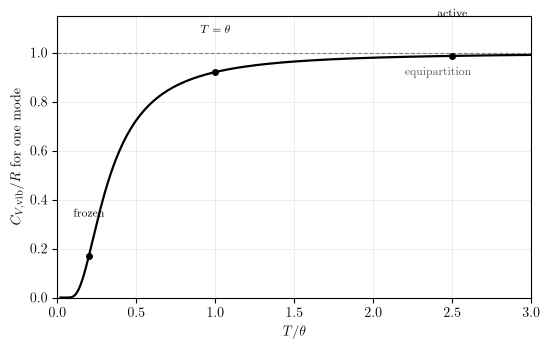

a mode is about half active at T = 0.34 theta, and 90% active at T = 1.1 theta


In [3]:
def einstein(T, nu_cm):
    """Cv contribution of one harmonic mode, in units of R. nu_cm in cm^-1."""
    u = C.h*C.c*100*np.asarray(nu_cm, float)/(C.k*np.asarray(T, float))
    return u**2*np.exp(u)/np.expm1(u)**2


def theta(nu_cm):
    """The mode's characteristic temperature, K."""
    return C.h*C.c*100*nu_cm/C.k


fig, ax = plt.subplots(figsize=(5.6, 3.6))
x = np.linspace(0.02, 3.0, 500)
ax.plot(x, einstein(x*theta(1000.0), 1000.0), "k-", lw=1.6)
ax.axhline(1.0, color="0.5", lw=0.8, ls="--")
ax.text(2.2, 0.94, "equipartition", fontsize=8, color="0.35", va="top")
for frac, lbl in ((0.2, "frozen"), (1.0, r"$T=\theta$"), (2.5, "active")):
    ax.plot([frac], [einstein(frac*theta(1000.0), 1000.0)], "ko", ms=4)
    ax.annotate(lbl, xy=(frac, float(einstein(frac*theta(1000.0), 1000.0))),
                xytext=(frac, float(einstein(frac*theta(1000.0), 1000.0)) + 0.16),
                fontsize=8, ha="center")
ax.set_xlabel(r"$T/\theta$"); ax.set_ylabel(r"$C_{V,\mathrm{vib}}/R$ for one mode")
ax.set_xlim(0, 3); ax.set_ylim(0, 1.15); ax.grid(color="0.9", lw=0.5)
fig.tight_layout(); plt.show()

print(f"a mode is about half active at T = 0.34 theta, and 90% active at T = 1.1 theta")

## 3. Methane, from its spectrum

Methane's nine modes are not nine different frequencies: the tetrahedral symmetry makes several
of them identical. Spectroscopy gives four distinct values, with degeneracies that add to nine.

| mode | $\tilde\nu$ (cm$^{-1}$) | degeneracy | $\theta$ (K) |
|---|---|---|---|
| $\nu_1$ symmetric stretch | 2917 | 1 | 4197 |
| $\nu_2$ bend | 1534 | 2 | 2207 |
| $\nu_3$ asymmetric stretch | 3019 | 3 | 4344 |
| $\nu_4$ bend | 1306 | 3 | 1879 |

Every one of those $\theta$ values is far above room temperature. That is the answer to §1: at
298 K the vibrations are barely started, so methane behaves almost like a molecule with no
vibrations at all, and

$$ C_P^{*} \longrightarrow \tfrac32 R + \tfrac32 R + R = 4R = 33.26 \ \mathrm{J/(mol\ K)} $$

**This is a floor, not a fitted value.** No nonlinear ideal gas can have a $C_P^{*}$ below $4R$,
because you cannot take away motions the molecule is already making. Remember it &mdash; §6
turns it into a test that a fitted polynomial can fail.

In [4]:
CH4_MODES = [(2917.0, 1, r"$\nu_1$ stretch"), (1534.0, 2, r"$\nu_2$ bend"),
             (3019.0, 3, r"$\nu_3$ stretch"), (1306.0, 3, r"$\nu_4$ bend")]
FLOOR = 4*R                      # 3/2 R translation + 3/2 R rotation + R


def cp_methane(T):
    """Ideal-gas Cp* of methane from its vibrational spectrum, J/(mol K). No fitting."""
    T = np.asarray(T, float)
    return FLOOR + R*sum(g*einstein(T, nu) for nu, g, _ in CH4_MODES)


def cp_janaf(T):
    """NIST-JANAF Shomate fit, 298-1300 K -- the reference, for checking only.
    Chase, NIST-JANAF Thermochemical Tables, 4th ed. (1998); webbook.nist.gov C74828."""
    t = np.asarray(T, float)/1000
    return -0.703029 + 108.4773*t - 42.52157*t**2 + 5.862788*t**3 + 0.678565/t**2


for nu, g, lbl in CH4_MODES:
    print(f"  {lbl:22s} {nu:6.0f} cm-1  x{g}   theta = {theta(nu):6.0f} K")
print(f"\n  floor 4R = {FLOOR:.3f} J/(mol K)")

Tj = np.linspace(298.15, 1300, 400)
err = cp_methane(Tj) - cp_janaf(Tj)
print(f"\n  vs NIST-JANAF over 298-1300 K: worst |difference| = {np.abs(err).max():.3f} J/(mol K)")
print(f"  at 298.15 K: derived {float(cp_methane(298.15)):.3f}, JANAF {float(cp_janaf(298.15)):.3f}")

  $\nu_1$ stretch          2917 cm-1  x1   theta =   4197 K
  $\nu_2$ bend             1534 cm-1  x2   theta =   2207 K
  $\nu_3$ stretch          3019 cm-1  x3   theta =   4344 K
  $\nu_4$ bend             1306 cm-1  x3   theta =   1879 K

  floor 4R = 33.258 J/(mol K)

  vs NIST-JANAF over 298-1300 K: worst |difference| = 0.034 J/(mol K)
  at 298.15 K: derived 35.640, JANAF 35.648


Agreement to **0.034 J/(mol K)** &mdash; one part in a thousand &mdash; over a range in which the
heat capacity more than doubles. Two things follow, and the second is the useful one:

- the harmonic model with four spectroscopic frequencies is quantitatively right for methane;
- and therefore **the curve can be trusted where no reference table exists.** NIST-JANAF's fit
  for methane starts at 298 K. The 6e needs $C_P^{*}$ down to 100 K for the methane chart of
  Fig. 3.3-2. Going below 298 K here is not extrapolating a fit &mdash; it is evaluating a
  physical model in a régime where it gets *simpler*, because modes only freeze out further.

The plot below shows where each mode switches on, and what the printed Appendix A.II row does
outside its range.

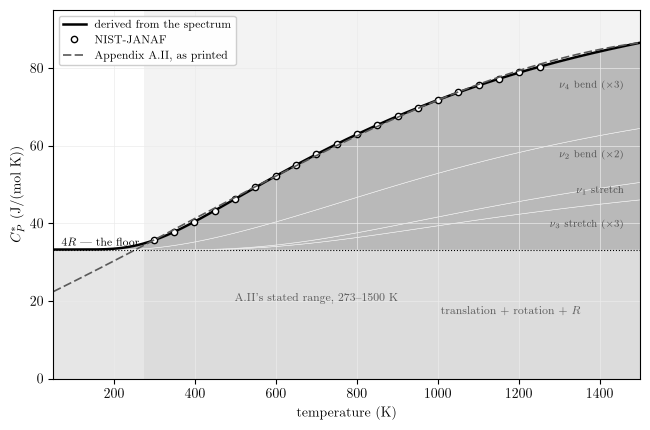

  T (K)   derived     A.II    error
    100     33.26    25.01   -24.8%
    150     33.27    27.65   -16.9%
    200     33.47    30.34    -9.4%
    273     34.81    34.30    -1.4%
    500     46.34    46.77     0.9%
   1000     71.79    71.76    -0.0%


In [5]:
A2_METHANE = (19.875, 5.021e-2, 1.268e-5, -11.004e-9)     # A.II as printed, 273-1500 K


def cp_poly(T, coef):
    T = np.asarray(T, float)
    return sum(c*T**i for i, c in enumerate(coef))


T = np.linspace(50, 1500, 600)
fig, ax = plt.subplots(figsize=(6.6, 4.4))

base = np.full_like(T, FLOOR)
ax.fill_between(T, 0, base, color="0.90", lw=0)
ax.text(1180, FLOOR/2, "translation + rotation + $R$", fontsize=8, ha="center", color="0.35")
for nu, g, lbl in sorted(CH4_MODES, key=lambda m: -m[0]):
    top = base + R*g*einstein(T, nu)
    ax.fill_between(T, base, top, color="0.75", lw=0.4, ec="w")
    ax.text(1460, (base[-1] + top[-1])/2, f"{lbl} " + (f"($\\times{g}$)" if g > 1 else ""),
            fontsize=7, va="center", ha="right", color="0.3")
    base = top

ax.plot(T, cp_methane(T), "k-", lw=1.8, label="derived from the spectrum")
ax.plot(Tj[::20], cp_janaf(Tj[::20]), "wo", mec="k", mew=1.0, ms=4.5, label="NIST-JANAF")
ax.plot(T, cp_poly(T, A2_METHANE), color="0.35", lw=1.2, ls=(0, (5, 2)),
        label="Appendix A.II, as printed")
ax.axhline(FLOOR, color="k", lw=0.8, ls=":")
ax.text(70, FLOOR + 1.0, r"$4R$ — the floor", fontsize=8)
ax.axvspan(273, 1500, color="0.55", alpha=0.10, lw=0)
ax.text(700, 20, "A.II's stated range, 273–1500 K", fontsize=8, ha="center", color="0.35")
ax.set_xlim(50, 1500); ax.set_ylim(0, 95)
ax.set_xlabel("temperature (K)"); ax.set_ylabel(r"$C_P^{*}$  (J/(mol K))")
ax.legend(fontsize=8, loc="upper left", framealpha=0.95)
ax.grid(color="0.92", lw=0.5)
fig.tight_layout(); plt.show()

print(f"{'T (K)':>7}{'derived':>10}{'A.II':>9}{'error':>9}")
for t in (100, 150, 200, 273, 500, 1000):
    d, a = float(cp_methane(t)), float(cp_poly(t, A2_METHANE))
    print(f"{t:7.0f}{d:10.2f}{a:9.2f}{100*(a-d)/d:8.1f}%")

The shaded bands are the individual modes switching on: the two bending modes first, around
600&ndash;800 K, then the stretches. At 100 K the whole vibrational contribution is $10^{-6}$ of
$R$ &mdash; methane there is, for thermodynamic purposes, a structureless ball with three ways to
move and three ways to spin.

And the printed A.II row, extrapolated below its range, **passes through the floor**: 25.0 at
100 K where $4R = 33.26$ is the least a methane molecule can have. A fit does not know about
floors. That is not a criticism of the fit &mdash; it is excellent inside 273&ndash;1500 K, which
is what it was made for &mdash; it is a statement about what a fit *is*.

## 4. Now treat the curve as an experiment

Everything above is a model. Suppose instead we had gone into a laboratory, measured
$C_P^{*}$ at twenty temperatures, and wanted the four coefficients Appendix A.II tabulates.

We can simulate exactly that, and we have an advantage no experimenter has: **we know the true
curve**, so we can add noise of a known size and see precisely what it costs. Real calorimetry
on a gas is good to a few tenths of a percent at best; take 0.3 % as our instrument.

In [6]:
def experiment(T_lo, T_hi, n, sigma_frac, seed=0):
    """Sample the true curve at n temperatures and add Gaussian noise."""
    g = np.random.default_rng(seed)
    Ts = np.linspace(T_lo, T_hi, n)
    truth = cp_methane(Ts)
    return Ts, truth + g.normal(0.0, sigma_frac*truth)


SIGMA = 0.003                       # 0.3% instrument
T_data, Cp_data = experiment(100, 500, 20, SIGMA)

coef_fit = np.polyfit(T_data, Cp_data, 3)[::-1]        # ascending powers
coef_true = np.polyfit(np.linspace(100, 500, 400),
                       cp_methane(np.linspace(100, 500, 400)), 3)[::-1]

print("cubic coefficients, in Appendix A.II's printed form (a, b x 1e2, c x 1e5, d x 1e9)")
print(f"{'':16s}{'a':>10}{'b':>10}{'c':>10}{'d':>10}")
for lbl, c in (("from noisy data", coef_fit), ("from the truth", coef_true)):
    print(f"{lbl:16s}{c[0]:10.3f}{c[1]*1e2:10.3f}{c[2]*1e5:10.3f}{c[3]*1e9:10.3f}")

Tp = np.linspace(100, 500, 400)
print(f"\nbut the CURVES agree: worst gap over 100-500 K = "
      f"{np.abs(cp_poly(Tp, coef_fit) - cp_poly(Tp, coef_true)).max():.3f} J/(mol K)")
print(f"the noise itself was {SIGMA*100:.1f}% of ~{cp_methane(300):.0f}, i.e. about "
      f"{SIGMA*float(cp_methane(300)):.2f} J/(mol K) per point")

cubic coefficients, in Appendix A.II's printed form (a, b x 1e2, c x 1e5, d x 1e9)
                         a         b         c         d
from noisy data     36.225    -4.178    14.809   -45.761
from the truth      37.080    -5.267    18.935   -92.322

but the CURVES agree: worst gap over 100-500 K = 0.133 J/(mol K)
the noise itself was 0.3% of ~36, i.e. about 0.11 J/(mol K) per point


This is the effect the Chapter 1 notebook meets with carbon dioxide, and here it can be
measured rather than asserted: **0.3 % noise on the data moves the individual coefficients by
tens of percent while moving the curve by a few hundredths of a J/(mol K).**

The reason is that $1$, $T$, $T^2$ and $T^3$ are nearly parallel over a range of a few hundred
kelvin &mdash; a large increase in one can be almost canceled by adjustments in the others.
The fit is not finding four physically meaningful numbers; it is finding *one curve*, and
reporting it in a basis that hides how well determined it is.

The next cell repeats the whole experiment 400 times with different noise, which turns "hides"
into a picture.

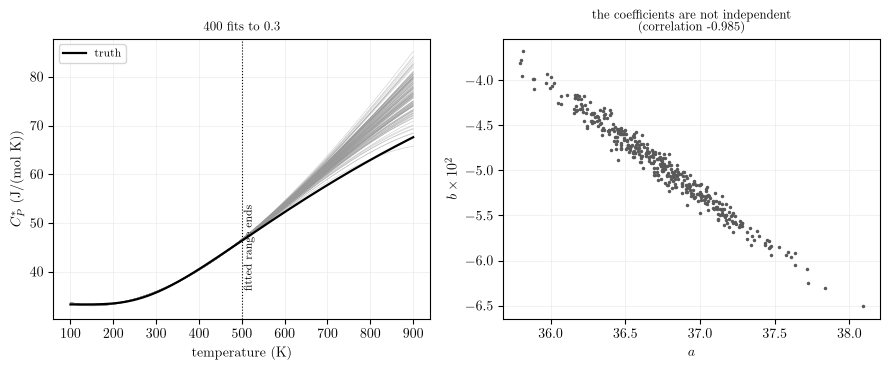

  a: mean    36.734   std    0.385   spread    1.0% of its own value
  b: mean    -4.945   std    0.473   spread    9.6% of its own value
  c: mean    18.061   std    1.738   spread    9.6% of its own value
  d: mean   -85.335   std   19.465   spread   22.8% of its own value

  scatter of the CURVE, inside the fitted range: 0.099 J/(mol K)
  scatter of the CURVE, 400 K beyond it:        4.043 J/(mol K)  (41x worse)


In [7]:
N_TRIALS = 400
coefs = np.array([np.polyfit(*experiment(100, 500, 20, SIGMA, seed=s), 3)[::-1]
                  for s in range(N_TRIALS)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.8))

# left: the fitted curves, inside the fitted range and beyond it
Tin = np.linspace(100, 500, 200)
Tout = np.linspace(500, 900, 200)
for c in coefs[:120]:
    ax1.plot(Tin, cp_poly(Tin, c), "-", color="0.6", lw=0.4, alpha=0.5)
    ax1.plot(Tout, cp_poly(Tout, c), "-", color="0.6", lw=0.4, alpha=0.5)
ax1.plot(np.r_[Tin, Tout], cp_methane(np.r_[Tin, Tout]), "k-", lw=1.6, label="truth")
ax1.axvline(500, color="k", lw=0.8, ls=":")
ax1.text(505, 36, "fitted range ends", fontsize=8, rotation=90, va="bottom")
ax1.set_xlabel("temperature (K)"); ax1.set_ylabel(r"$C_P^{*}$  (J/(mol K))")
ax1.set_title("400 fits to 0.3%-noisy data", fontsize=9)
ax1.legend(fontsize=8); ax1.grid(color="0.92", lw=0.5)

# right: two of the coefficients against each other
ax2.plot(coefs[:, 0], coefs[:, 1]*1e2, ".", color="0.35", ms=3)
ax2.set_xlabel("$a$"); ax2.set_ylabel(r"$b \times 10^{2}$")
ax2.set_title(f"the coefficients are not independent\n(correlation "
              f"{np.corrcoef(coefs[:, 0], coefs[:, 1])[0, 1]:+.3f})", fontsize=9)
ax2.grid(color="0.92", lw=0.5)
fig.tight_layout(); plt.show()

for i, (nm, scale) in enumerate((("a", 1), ("b", 1e2), ("c", 1e5), ("d", 1e9))):
    v = coefs[:, i]*scale
    print(f"  {nm}: mean {v.mean():9.3f}   std {v.std():8.3f}   "
          f"spread {100*v.std()/abs(v.mean()):6.1f}% of its own value")
band_in = np.array([cp_poly(np.linspace(100, 500, 50), c) for c in coefs])
band_out = np.array([cp_poly(np.linspace(500, 900, 50), c) for c in coefs])
print(f"\n  scatter of the CURVE, inside the fitted range: "
      f"{band_in.std(axis=0).max():.3f} J/(mol K)")
print(f"  scatter of the CURVE, 400 K beyond it:        "
      f"{band_out.std(axis=0).max():.3f} J/(mol K)  "
      f"({band_out.std(axis=0).max()/band_in.std(axis=0).max():.0f}x worse)")

The left panel is the practical lesson. Inside the fitted range the 400 curves are
indistinguishable &mdash; a hair's breadth wide. Past the last data point they fan out
immediately, and the fan widens faster than the distance traveled. **Nothing in the fit warns
you about this**: the residuals were fine, the correlation coefficient was excellent, and the
answer is still worthless 400 K out.

The right panel shows why the coefficients themselves should not be quoted individually: $a$ and $b$ are
almost perfectly anti-correlated, so a fit that reports $a$ high will report $b$ low, and the
two errors cancel *inside the range where they were fitted together*. Quote a coefficient to
four figures and you are reporting noise; quote the curve and you are reporting the measurement.

## 5. What the fitting range does &mdash; reproducing Appendix A.II's methane problem

Appendix A.II fitted methane over **273&ndash;1500 K**, which is a sensible range for a fuel.
Fig. 3.3-2 needs the same fluid down to 100 K. This is the experiment that shows what that costs
&mdash; and it needs no noise at all, because it is not about noise.

In [8]:
RANGES = [(273, 1500, "A.II's own range"), (100, 500, "the cryogenic row"),
          (100, 1500, "both at once")]
Tq = np.linspace(100, 400, 600)                 # the span Fig. 3.3-2 actually uses

print(f"{'fitted over':>22}   {'max |dCp*|':>11}{'dH':>12}{'dS':>10}   at 100 K")
for lo, hi, lbl in RANGES:
    Tf = np.linspace(lo, hi, 2000)
    c = np.polyfit(Tf, cp_methane(Tf), 3)[::-1]
    e = cp_poly(Tq, c) - cp_methane(Tq)
    print(f"{lbl:>22}   {np.abs(e).max():8.3f}   {np.trapezoid(e, Tq):+9.1f} J/mol"
          f"{np.trapezoid(e/Tq, Tq):+9.3f}   {float(cp_poly(100, c)):6.2f}"
          f"{'  BELOW THE FLOOR' if cp_poly(100, c) < FLOOR else ''}")

e = cp_poly(Tq, A2_METHANE) - cp_methane(Tq)
print(f"{'A.II as printed':>22}   {np.abs(e).max():8.3f}   {np.trapezoid(e, Tq):+9.1f} J/mol"
      f"{np.trapezoid(e/Tq, Tq):+9.3f}   {float(cp_poly(100, A2_METHANE)):6.2f}  BELOW THE FLOOR")
print(f"\n  for scale, methane's heat of vaporization is 8190 J/mol")

           fitted over    max |dCp*|          dH        dS   at 100 K
      A.II's own range     10.299      -958.1 J/mol   -6.288    22.96  BELOW THE FLOOR
     the cryogenic row      0.362        +2.3 J/mol   +0.011    33.62
          both at once      2.708      +107.7 J/mol   -0.248    30.55  BELOW THE FLOOR
       A.II as printed      8.246      -635.2 J/mol   -4.521    25.01  BELOW THE FLOOR

  for scale, methane's heat of vaporization is 8190 J/mol


Two separate results.

**A wider fit is not a better fit.** Fitting 100&ndash;1500 K in one cubic is worse over
100&ndash;400 K than fitting 100&ndash;500 K, even though it saw all the same data and more.
A cubic has four parameters to spend; asked to cover a range over which the heat capacity
triples, it spends them where the data is densest and the curvature largest, which is not where
your problem is. **The range is part of the correlation**, as much as the coefficients are, and
that is why Appendix A.II prints it in its own column.

**And the failure has a sign you can check without a reference table.** A fit that returns
$C_P^{*} < 4R$ for a nonlinear molecule is wrong &mdash; no measurement, no comparison
and no statistics required, only the knowledge that a molecule cannot un-rotate. The 6e's
cryogenic methane row exists because of exactly this test.

## What this notebook shows

- **A heat capacity is a count of the ways a molecule can move**, plus a quantum correction for
  the ones it cannot afford yet. Four spectroscopic frequencies and no fitted parameters
  reproduce the standard reference table for methane to one part in a thousand.
- **Equipartition is the high-temperature limit, and $4R$ is the low-temperature one.** Both are
  exact, and both are counting arguments. The same counting gives the DuLong&ndash;Petit value
  $3NR$ for a solid (Eq. 3.3-12) &mdash; and fails there for the same reason, which is why
  silicon's heat capacity at 25 &deg;C is well below it.
- **Fitting turns a curve into four numbers, and the four numbers are not the curve.** Noise of
  0.3 % moves them by tens of percent while moving the curve by hundredths of a J/(mol K),
  because the powers of $T$ are nearly parallel over any finite range.
- **A fit's silence about its range is the dangerous part.** The residuals cannot tell you that
  the curve is wrong 400 K past the last data point, and no goodness-of-fit statistic will.
- **Physics beats statistics for detecting a bad extrapolation.** The floor test takes one line
  and no data.

## Your turn

1. **Nitrogen is linear.** Redo &sect;1 and &sect;3 for N$_2$: one vibrational mode at
   2359 cm$^{-1}$, two rotational axes, so the floor is $\tfrac72 R$. How high must the
   temperature be before that single mode contributes 1 J/(mol K)? Compare with Appendix A.II's
   nitrogen row over 100&ndash;300 K &mdash; why is it so much better behaved than methane's?
2. **Change the instrument.** Re-run &sect;4 with $\sigma$ = 0.03 % and 3 %. How does the width
   of the fan scale with the noise &mdash; linearly, or faster? How does it scale with the
   *number* of data points at fixed noise?
3. **Spend the parameters better.** Fit $C_P^{*}$ over 100&ndash;1500 K with a cubic in $T$, and
   then with a cubic in $\ln T$, or with the Shomate form (which carries a $1/T^2$ term). Which basis is improved most by its fourth parameter? What does that suggest about *why* Appendix A.II splits
   compounds into temperature ranges instead of using a better function?
4. **Find the floor violation automatically.** Write a check that takes any four A.II
   coefficients and a molecule's structure and reports the temperature below which the row
   becomes unphysical. Run it over the whole of `data/pure_property.csv`. How many rows fail
   inside a range someone might plausibly use?
5. **Where does the harmonic model break?** It assumes each mode is a perfect spring. Real
   bonds soften as they stretch, so at high temperature the true $C_P^{*}$ runs slightly above
   the harmonic prediction. Find where the &sect;3 comparison starts to drift, and estimate the
   temperature at which anharmonicity is worth 1 %.
6. **The solid-state counterpart.** Eq. 3.3-12 gives $C_P \approx 3NR$ for a solid. Look up the
   Debye temperature of silicon and of lead, and predict which one obeys DuLong&ndash;Petit at
   25 &deg;C. Then check against the values printed in &sect;3.3.